# CAB420 Metric Learning, Bonus Example: Arc Face
Dr Simon Denman (s.denman@qut.edu.au)

### What is a "Bonus" Example?

These are extra examples that cover content outside the scope of CAB420. It exists becuase of one or more of the following reasons:
* It's closely related to other stuff we're looking at and I wanted to include it, but the course has too much content already, so I punted it here; 
* It's interesting;
* Someone (probably multiple someones if I wrote an example) has asked a question about it before.

You can freely ignore this example if you want. You really don't have to be reading this. You could go outside, go read a book, have a nap, take up a hobby, whatever you want really. The point I want to make here **this example really is optional**. Things here won't appear on an exam, or in an assignment (though you could use this in an assignment if you wanted). But if you're interested, this is here, and if you're reading this, so are you. 

Some things to note with bonus examples:
* These may gloss over details that elsewhere get more coverage. I may skip plots I'd normally include, or gloss over other details. The expecatation is that if you're reading this, you've looked at all the "core" examples and are comfortable with what they're doing. 
* Some bits of code might not be as well explained or explored as you're used to in the other examples. These examples are here for interested students looking to extend their knowledge, and I'm assuming if you're here, you're comfortable figuring code out, debugging stuff, and generally googling about to help work out what something is doing.
* There's no Tl;DR section at the top. If you're here, I'm assuming it's because you're interested and want all the gory details and don't just need the quick summary at the top.
* While my regular examples (the "core" ones) certainly contain their fare share of silly remarks and typos, expect the level of flippancy and the prevalence of typos increase in a bonus example. 

That said, as always, if you are stuggling to follow what I've got in here please shoot me a message. The aim is still for this to be clear enough to follow afterall.

## Overview

In this example we're taking a look at the Additive Angular Margin Loss, which was proposed in the paper [ArcFace: Additive Angular Margin Loss for Deep Face Recognition](https://arxiv.org/abs/1801.07698). 

To explain what this does, let's start by thinking about what our contrastive and triplet losses do. Both of those try to separate samples of different classes by some margin (typically 1 when we use normalised features). Often times when I'm discussing these things in classes, I talk about this idea of pushing embeddings from different classes into different corners of the hyper-cube described by our embedding space, but this isn't strictly what's happening - these losses will just to try [keep things separated](https://www.youtube.com/watch?v=1jOk8dk-qaU), but won't actually enfore any other sort of structure on the embedding space.

The Additive Angular Margin Loss (also commonly just called the Arc loss) tries to address this. With this loss, we have our same backbone network from which we get an embedding, which we promptly normalise. The normalisation process means that we're mapping our feature vectors to a hyper-sphere, but then rather than simply try to put some arbitrarary distance between samples of different classes by adding a margin, we apply the margin to the angle between the classes.

### Where does this fit into all the other CAB420 content?

This example is an extension to the metric learning content, and considers an alternate loss formulation that can provide better separation between classes. It build directly on top of the rest of the metric learning work, as well as having very strong links to the earlier examples that looked at classification using deep nets.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import random
import numpy
import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import math
import tensorflow as tf

tf.config.optimizer.set_jit(False)

### The Data

It's fashion MNIST again. Nothing to see here. Move along.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1) / 255
y_train = keras.utils.to_categorical(y_train.reshape(y_train.shape[0], 1))
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1) / 255
y_test = keras.utils.to_categorical(y_test.reshape(y_test.shape[0], 1))

### Some Network Building Functions

This will again seem familar. Once again just our usual building blocks for a simple VGG backbone.

In [3]:
def conv_block(inputs, filters, spatial_dropout = 0.0, max_pool = True):

    x = layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(filters=filters, kernel_size=(3,3), padding='same', activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if (spatial_dropout > 0.0):
        x = layers.SpatialDropout2D(spatial_dropout)(x)
    if (max_pool == True):
        x = layers.MaxPool2D(pool_size=(2, 2))(x)
    
    return x

def fc_block(inputs, size, dropout):
    x = layers.Dense(size, activation=None)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if (dropout > 0.0):
        x = layers.Dropout(dropout)(x)
    
    return x

def vgg_net(inputs, filters, fc, spatial_dropout = 0.0, dropout = 0.0):
    
    x = inputs
    for idx,i in enumerate(filters):
        x = conv_block(x, i, spatial_dropout, not (idx==len(filters) - 1))
    
    x = layers.Flatten()(x)
    
    for i in fc:
        x = fc_block(x, i, dropout)
        
    return x

### ARC Loss

Now for some new stuff.

#### Softmax

First up, let's revist softmax. This is the softmax loss function:

$-\frac{1}{N}\sum_{i=1}^N log \frac{$e^{W_{y_i}^T x_i + b_{y_i}}$}{$\sum_{j=1}^N  e^{W_{y_j}^T x_j + b_{y_j}}$}$

This looks awful, but it's actually not that bad. Consider this bit in the numerator: $W_{y_i}^T x_i + b_{y_i}$, this is just the logit for some class, $i$. The output of a dense layer (i.e. the layer on which a softmax loss would be applied) is just $y = Wx + b$, and so any one element of $y$ can be expressed as $W_{y_i}^T x_i + b_{y_i}$. So on the numerator, we take $e$ to the power of that output. If our logit is big, our numerator is big. Here, $i$ is the ground truth class, so if our network is returning a nice big logit for our ground truth class we get a nice big number.

The denominator is then the sum of $e$ to the power of all logits. If the logits for all the other classes are tiny, then the sum here is going to be about the same as for the numerator. If the logits for the other classes (i.e. not $i$) are also nice and big, or bigger than the one we ahve for class $i$, we'll get a much larger denominator than numerator.

So if we have the first condition where our logit for class $i$ is way bigger than the rest, the numerator and denominator come to something similar and we'll compute the log of something close to 1, which will give a result close to 0. That makes sense, as that's the behaviour that we want, and so we'd expect a small loss. If we have the second condition, where class $i$ does not clearly have the biggest logit, the fraction will evaluate to a smaller value, and we'll get increasingly large negative values from the log as the fraction get's smaller and smaller. Again, this works out. Note that we have the negative sign out the front, so large negative values, which indicate increasingly wrong decisions, become large positive values (i.e. a large loss).

#### Arc Loss

Now, let's consider the Arc Loss function:

$-\frac{1}{N}\sum_{i=1}^{N} log \frac{e^{cos(\theta_{y_i} + m)}} {e^{cos(\theta_{y_i} + m)} + \sum_{j=1, j\neq y_i}^{N}e^{cos(\theta_j)} } $

Again this looks fairly horrible, but it's also quite similar to our softmax. The big difference is that our $W_{y_i}^T x_i + b_{y_i}$ has been replaced with various $cos \theta$ operations. This brings us to the central idea of the Arc Loss, we want to make sure that embeddings from each class are separated by some angle. The structure of the loss is fundamentally the same as for our softmax, for a given sample we're looking at the log of e to the power of something derived from the logit of the class of interest, divided by the sum of e the power of something derived from the logits of all classes. The difference now though is that rather than look at the actual logit, we're looking at the angle between the logit and some vector - this is what that $\theta$ thing is.

#### Where the f*ck does $\theta$ come from?

If you're still here, well done.

So the trick with Arc loss if getting those angles. Let's start from some input, $I$, which we'll pass through a network, $N$, to get some embedding, $f$, so we've got $f = N(I)$. We'll then normalise that embedding, so it becomes a point on a hyper-sphere, $\hat{f} = ||f||_2$.

This sounds like contrastive or triplet loss so far, but rather than compare different $\hat{f}$'s directly, we'll compare them to some other weight matrix, $W$. $W$ is a $d \times c$, where $d$ is the dimensionality of $f$ and $c$ is the number of classes. We'll normalise that weight matrix too, so we have $\hat{W} = ||W||_2$. We can think about $W$ as having a $c$ vectors (each of dimension $d$) in it, one for each class. Think of each of these $c$ vectors being a prototype feature for a given class, so with this loss we're going to aim to have the angle between a sample and it's corresponding vector being nice and small, and then have the vectors for each class separated by some margin. This way, we get out classes nice and well separated. Handily, we can use the dot product to get those angles for us, $cos(\theta) = \hat{W} \cdot \hat{f}$, and then $\theta_i$ will give us angle between our feature and the weight vector that corresponds to class $i$.

So, bringing this back to our Arc loss function:

$-\frac{1}{N}\sum_{i=1}^{N} log \frac{e^{cos(\theta_{y_i} + m)}} {e^{cos(\theta_{y_i} + m)} + \sum_{j=1, j\neq y_i}^{N}e^{cos(\theta_j)} } $

Starting with the numerator,  $cos(\theta_{y_i} + m)$ is the cosine of the angle between our target embedding and the correct class, so ideally these would be nice and close, which means a small angle, and thus a cosine close to 1 (remember, $cos(0) = 1$). Then we have the denominator. Like with the softmax function, we now have the sum of the angle between the target embedding and all classes (with the margin added for the true class). Again the idea here is the same as the softmax, so if the embedding is much closer to the target class than the rest we'll get a value closer to 1 thus the loss will be close to 0; and if not we'll get a large negative number (but we've got the negative sign out the front to fix all that) and thus a larger loss.

#### So is this just a softmax on steroids?

Somewhat. You'll see in the implementation we actually use a softmax as part of all of this, but there are two critical differences:
* We've got that margin, which tries to get better separation between classes than we otherwise would
* We're looking at angles rather than the raw logits, which helps getting a better distribution of classes within the embedding space

In [4]:
class ArcFace(keras.Layer):
    # if in doubt, leave s amd m alone, make sure you set the number of classes though
    def __init__(self, n_classes=10, s=30.0, m=0.50, regularizer=None, **kwargs):
        super(ArcFace, self).__init__(**kwargs)
        self.n_classes = n_classes
        self.s = s
        self.m = m
        self.regularizer = None

    def build(self, input_shape):
        super(ArcFace, self).build(input_shape[0])
        # a weight matrix. This is going to store what I think of as the prototype vectors that represent each class
        self.W = self.add_weight(name='W',
                                shape=(input_shape[0][-1], self.n_classes),
                                initializer='glorot_uniform',
                                trainable=True,
                                regularizer=self.regularizer)
        print(self.W)

    def call(self, inputs, training=None):
        # this where the magic happens
        # first unpack the inputs, here we have our incomming logits, and the ground truth
        x, y = inputs
        # normalize feature
        x = keras.utils.normalize(x, order=2, axis=1)
        # normalize weights
        W = keras.utils.normalize(self.W, order=2, axis=0)
        # dot product
        logits = keras.ops.matmul(x, W)
        
        # add margin
        # clip logits to prevent zero division when backward
        theta = keras.ops.arccos(keras.ops.clip(logits, -1.0 + keras.config.epsilon(), 1.0 - keras.config.epsilon()))
        # add the margin to the logits
        target_logits = keras.ops.cos(theta + self.m)
        # apply a mask such that we get (logits + margin) for the target class, and just the logits elsewhere
        logits = logits * (1 - y) + target_logits * y
        # feature re-scale
        logits *= self.s
        # compute the softmax, get the output
        out = keras.ops.softmax(logits)

        return out

    def compute_output_shape(self, input_shape):
        return (None, self.n_classes)

### The Network

Let's put arc loss into practice now. We'll use our usual simple network, but we'll have the arc loss layer at the end. One technically poor choice I'm making here is using an embedding size of 2. This is not a performance decision, but one I'm making for visualisation purposes. If you want to use this stuff in anger, you'd change that number.

One other cool thing to note is the actual loss function we use in compile - it's categorical cross entropy. The arc loss stuff is all about manipulating the logits to give us some desireable properties in the embedding space (i.e. well separated classes), and then we just use regular old categorical cross entropy to do the rest.

In [5]:
# NOTE - this is 2 only for visualisation reasons, for series stuff, you'd make this bigger
embedding_size = 2

# backbone, same as usual
dummy_input = keras.Input((28, 28, 1))
base_network = vgg_net(dummy_input, [8, 16, 32], [256], 0.2, 0)
embedding_layer = layers.Dense(embedding_size, activation=None, name='embedding')(base_network)

# second input for the labels, because arc loss needs to know that
label = keras.Input(shape=(10,))
# normalise embeddings
embedding_layer = layers.BatchNormalization()(embedding_layer)
# arc loss layer
output = ArcFace(n_classes=10)([embedding_layer, label])
# build the network
arc_network = keras.Model([dummy_input, label], output, name='arc')

arc_network.summary()
# note the loss - CCE
arc_network.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'], jit_compile=False)

<KerasVariable shape=(2, 10), dtype=float32, path=arc_face/W>


Model: "arc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28, 8) │         80 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28, 8) │        584 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28, 8) │         32 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 28, 28, 8) │          0 │ activation[0][0]  │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14, 8) │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      1,168 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │      2,320 │ conv2d_2[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 14, 14,    │          0 │ activation_1[0][… │
│ (SpatialDropout2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 16)  │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 32)  │      4,640 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 32)  │      9,248 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 32)  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 7, 7, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_2 │ (None, 7, 7, 32)  │          0 │ activation_2[0][… │
│ (SpatialDropout2D)  │                   │            │                 

 Total params: 421,494 (1.61 MB)

 Trainable params: 420,866 (1.61 MB)

 Non-trainable params: 628 (2.45 KB)

Now time for training. Here I'm going to do something weird. What I could (should??) do is this 
```
arc_network.fit([x_train, y_train], y_train, batch_size=512, epochs=100, verbose=False, validation_data=([x_test, y_test], y_test))
```
But that won't help me draw pretty pictures. So what I'll do instead is train 20 epochs at a time, and visualise what's happening in $W$ (that weight vector that we're learning in the arc loss function) as we go to see how that changes. This will help make sense of what this thing is doing.

In [6]:
weights = [];
weights.append(keras.utils.normalize(arc_network.layers[-1].W, order=2, axis=0))

epochs_per_iteration = 2
for i in range(5):
    arc_network.fit([x_train, y_train], y_train, batch_size=512, epochs=20, verbose=False, validation_data=([x_test, y_test], y_test))
    weights.append(keras.utils.normalize(arc_network.layers[-1].W, order=2, axis=0))

### Pretty Pictures

My network is trained. Let's do stuff.

First up, I'm going to pull out a network that ends at the batch normalisation before the arc loss layer, i.e. I'll cut off the arc loss layer.

Then I'll get some embeddings,. If I wanted to I could normalise those, but I've commented that out for now (I think the pictures are prettier if I don't do that). If I had more than two dimensions I might also want to use t-SNE.

In [7]:
model = keras.Model(inputs=arc_network.input[0], outputs=arc_network.layers[-3].output)
model.compile(jit_compile=False)

embedded_train_features = model.predict(x_train, verbose=0)
#embedded_train_features /= numpy.linalg.norm(embedded_train_features, axis=1, keepdims=True)

embedded_test_features = model.predict(x_test, verbose=0)
#embedded_test_features /= numpy.linalg.norm(embedded_test_features, axis=1, keepdims=True)

if (embedding_size > 2):
    tsne_train_embeddings = TSNE(random_state=4).fit_transform(embedded_train_features)
    tsne_test_embeddings = TSNE(random_state=4).fit_transform(embedded_test_features)
else:
    tsne_train_embeddings = embedded_train_features
    tsne_test_embeddings = embedded_test_features

And now for the embedding plots. I've got eight of my ten classes as (more or less) evenly spaced lines projecting out from the origin. Aside from looking cool, you can see we've got great separation between most of the classes.

For three classes (pullover, coat, and shirt) we don't get great separation - though these are three classes where the ambiguity is perhaps somewhat understandable.

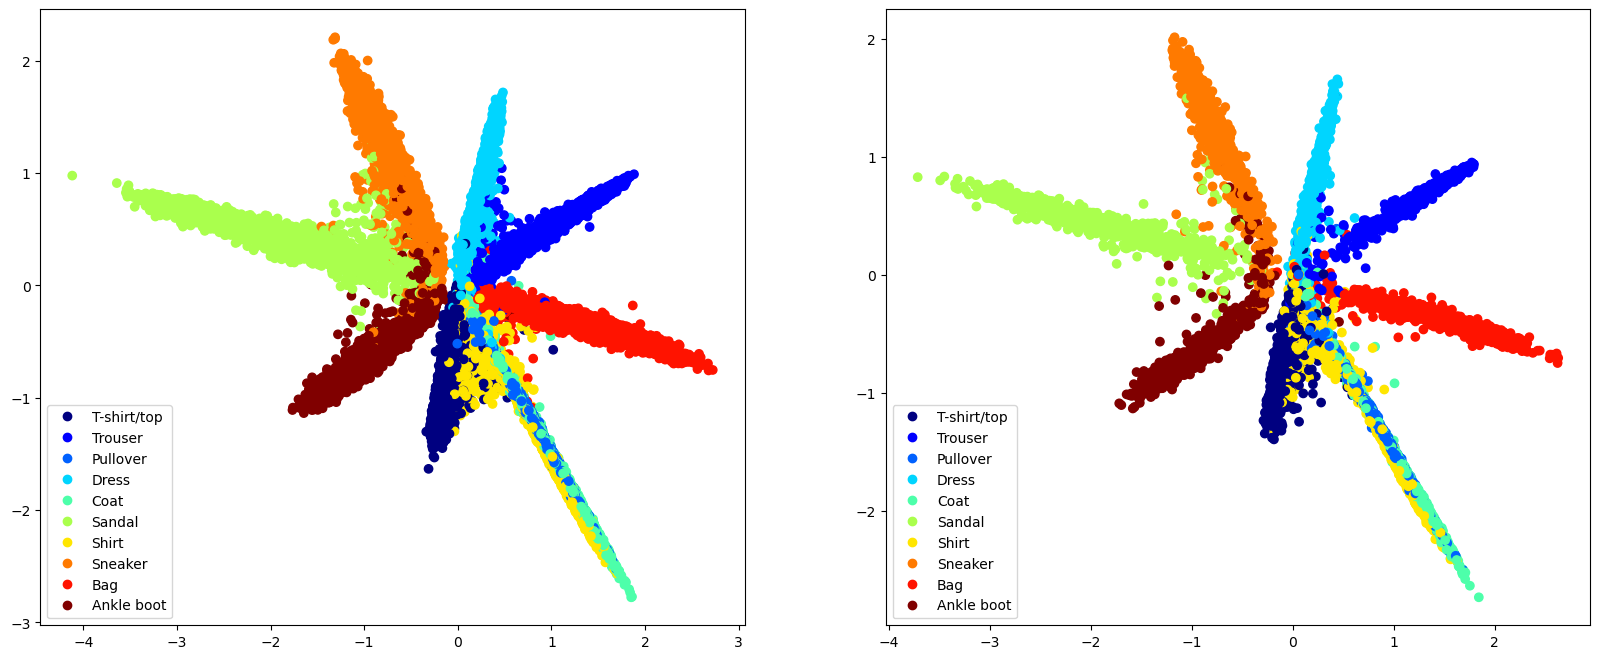

In [14]:
fig = plt.figure(figsize=[20, 8])
ax = fig.add_subplot(1, 2, 1)
scatter = ax.scatter(tsne_train_embeddings[:,0], tsne_train_embeddings[:,1], c = keras.ops.argmax(y_train, axis=1), cmap='jet');
ax.legend(handles=scatter.legend_elements()[0], labels=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])
ax = fig.add_subplot(1, 2, 2)
ax.scatter(embedded_test_features[:,0], embedded_test_features[:,1], c = keras.ops.argmax(y_test, axis=1), cmap='jet');
ax.legend(handles=scatter.legend_elements()[0], labels=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

Now let's have a look at how those weights in the arc loss layer change over time. 

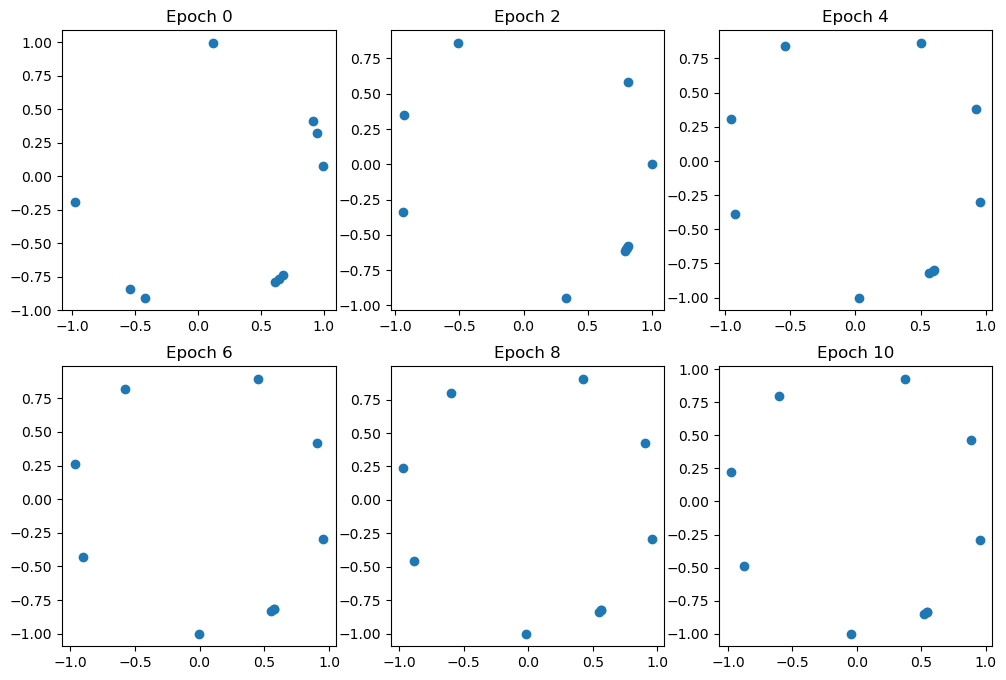

In [9]:
fig = plt.figure(figsize=[12, 8])
for i,w in enumerate(weights):
    ax = fig.add_subplot(2, 3, i+1)
    ax.scatter(w[0,:], w[1,:])
    ax.set_title('Epoch %d' % (i*epochs_per_iteration))

At epoch 0, things are not well spread, but we quickly see classes spread out and distribute themselves about a unit circle. Those who are still awake will note that we don't have 10 clear points, rather we've only got 8 - as we saw above we have those three classes that are grouped together.

If we trained this for longer, we'd start to see that little cluster break further apart and separation would improve. We could also use a larger embedding space - but then we couldn't do all these cool little 2D plots, and where would the fun in that be.

### Final Thoughts

So, what have we learned today?

Arc loss is cool and can help us create lots of cool plots. More to the point, it does a really good job of learning an embedding space where different classes are well separated by the angle between them. Arc loss has enjoyed a mountain of success in the biometric domain, and is a really good option when dealing with situations with high numbers of classes.